<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week12/Day2/DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Challenge - Statistics for Machine Learning
Customer churn analysis

# Applying Inferential Statistics
Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

The most appropriate test to analyse data here is Frequentist test.

In [1]:
#Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")


# For modeling
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression  # Logistic
from sklearn.ensemble import RandomForestClassifier   # Random Forest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc

In [2]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [5]:
file_1 = pd.read_csv('Churn_Modelling.csv')

In [6]:
# make into a dataframe called df
df = pd.DataFrame(file_1)

In [7]:
# output the first 5 lines
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
# Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1),
# respectively

df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

# Hypothesis 1: Age

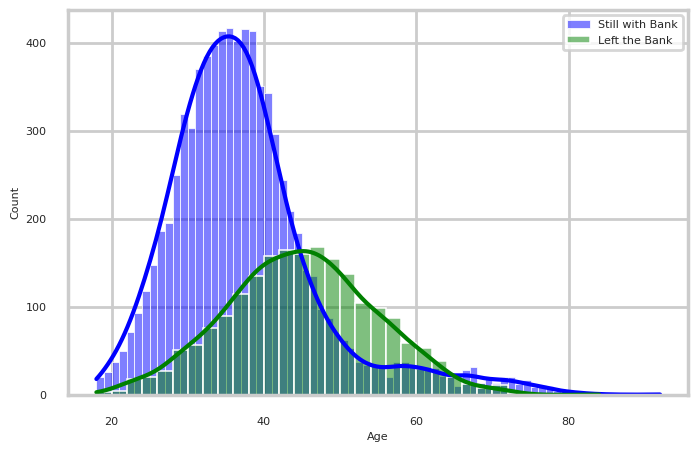

In [9]:
#  Plot the age distribution for customers who stayed with the bank and those who left using seaborn,
# with different colors for each group and a legend.

sns.histplot(df_0['Age'], color='blue', label='Still with Bank', kde=True)
sns.histplot(df_1['Age'], color='green', label='Left the Bank', kde=True)

plt.legend(fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel(plt.gca().get_xlabel(), fontsize=8)
plt.ylabel(plt.gca().get_ylabel(), fontsize=8)
plt.show()

In [10]:
# Calculate the mean and standard deviation of the age for customers who stayed with the bank.

df_0.Age.mean() , df_0.Age.std()

(np.float64(37.40838879819164), 10.125362911047631)

In [11]:
# Calculate the mean and standard deviation of the age for customers who left the bank.

df_1.Age.mean() , df_1.Age.std()

(np.float64(44.8379970544919), 9.761561555507132)

In [12]:
# Perform a t-test to compare the ages of customers who stayed and left the bank.

print("H0: μ(stayed) = μ(left)")
print("H1: μ(stayed) ≠ μ(left)")
print("α = 0.05")

# t-test (Welch's t-test: does not assume equal variances)
t_stat, p_value = scipy.stats.ttest_ind(df_0.Age, df_1.Age, equal_var=False)

print("\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Mean values
mean_stayed = df_0['Age'].mean()
mean_left = df_1['Age'].mean()

print(f"\nMean age (stayed): {mean_stayed:.1f}")
print(f"Mean age (left): {mean_left:.1f}")
print(f'difference: {(mean_stayed - mean_left ):.1f}')

# Interpretation
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject H0 (p = {p_value:.6f} < {alpha})")
    print("There is a statistically significant difference in mean age between customers who stayed and those who left.")
else:
    print(f"\nConclusion: Fail to reject H0 (p = {p_value:.6f} ≥ {alpha})")
    print("There is no statistically significant difference in mean age between the two groups.")

# Customers who left the bank are ~7 years older on average, which suggests age is strongly associated with churn.

H0: μ(stayed) = μ(left)
H1: μ(stayed) ≠ μ(left)
α = 0.05

Results:
T-statistic: -30.4192
P-value: 0.000000

Mean age (stayed): 37.4
Mean age (left): 44.8
difference: -7.4

Conclusion: Reject H0 (p = 0.000000 < 0.05)
There is a statistically significant difference in mean age between customers who stayed and those who left.


# Using Bootstrapping

In [14]:
# Take original data
# Resample with replacement
# Calculate a statistic of interest (mean, standard deviation, etc.)
# Repeat thousands of times

## Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
    bs_s = np.empty(size)  # creates an “empty container” to store results
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data), replace=True)  # takes a random sample, with replacement, of the same size as the original data
        bs_s[i] = func(bs_abc)  # applies a function (e.g., std, mean)
    return bs_s   # returns simulated results

In [13]:
# Calculate the difference in means and shift the ages to the overall mean.

# Difference in observed mean ages between those who left and those who didn't
obs_diff = df_1['Age'].mean() - df_0['Age'].mean()
print(obs_diff.round(2))

# Overall mean age
overall_mean = df['Age'].mean()
print(overall_mean.round(2))

# ✔ “remove the original differences between the groups” and leave them all with the SAME mean
# ✔ Objective: to simulate “there is no real difference between groups”
df_0_shifted = df_0['Age'] - df_0['Age'].mean() + overall_mean
df_1_shifted = df_1['Age'] - df_1['Age'].mean() + overall_mean
display (df_0_shifted.head())
display(df_1_shifted.head())

7.43
38.92


,Age
1,42.513411
3,40.513411
4,44.513411
6,51.513411
8,45.513411


,Age
0,36.083803
2,36.083803
5,38.083803
7,23.083803
16,52.083803


In [15]:
# Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.

# Bootstrap parameters
n_iterations = 1000
boot_std_0, boot_std_1 = [], []

# Bootstrap sampling
for _ in range(n_iterations):
    sample_0 = df_0['Age'].sample(frac=1, replace=True)
    sample_1 = df_1['Age'].sample(frac=1, replace=True)
    boot_std_0.append(sample_0.std())
    boot_std_1.append(sample_1.std())

# Results
boot_std_0 = np.array(boot_std_0)
boot_std_1 = np.array(boot_std_1)
diff = boot_std_0 - boot_std_1

print(f"Std (Stayed):     {boot_std_0.mean():.4f} ± {boot_std_0.std():.4f}")        #original data: 10.1254
print(f"Std (Left):       {boot_std_1.mean():.4f} ± {boot_std_1.std():.4f}")        #original data: 9.7616
print(f"Difference (0-1): {diff.mean():.4f} ± {diff.std():.4f}")

Std (Stayed):     10.1215 ± 0.1267
Std (Left):       9.7619 ± 0.1541
Difference (0-1): 0.3596 ± 0.1958


In [16]:
# Calculate the p-value by comparing the difference in means to the bootstrap distribution.

# mean difference bootstrap
def bootstrap_mean_diff(a, b, size=1000):
  diffs = np.zeros(size)
  for i in range(size):
     a_sample = np.random.choice(a, size=len(a), replace=True)
     b_sample = np.random.choice(b, size=len(b), replace=True)
     diffs[i] = np.mean(b_sample) - np.mean(a_sample)
  return diffs

bs_diffs = bootstrap_mean_diff(df_0_shifted, df_1_shifted)

# Calculate the p-value by comparing the difference in means to the bootstrap distribution.
# p-value (two-tailed)

# 👉 “How many times does chance produce a difference equal to or greater than the real one?”
p_value = np.mean(np.abs(bs_diffs) >= np.abs(obs_diff))
print(f"Observed difference: {obs_diff:.4f}")
print(f"P-value: {p_value:.6f}")


Observed difference: 7.4296
P-value: 0.000000


In [17]:
alpha = 0.05

if p_value < alpha:
    print("\nConclusion: Reject H0")
    print("There is a statistically significant difference in ages between the two groups.")
else:
    print("\nConclusion: Fail to reject H0")
    print("There is no statistically significant difference in ages between the two groups.")

# Bootstrap results confirm the t-test findings, increasing confidence in the results.


Conclusion: Reject H0
There is a statistically significant difference in ages between the two groups.


# Conclusion
Do we reject the Null Hypothesis ? Why ?

We reject the null hypothesis because the p-value is less than 0.05 (α). The observed difference in mean ages between the two groups (~7 years) is unlikely due to chance alone, indicating a statistically significant difference.

# Hypothesis 2: Credit Score

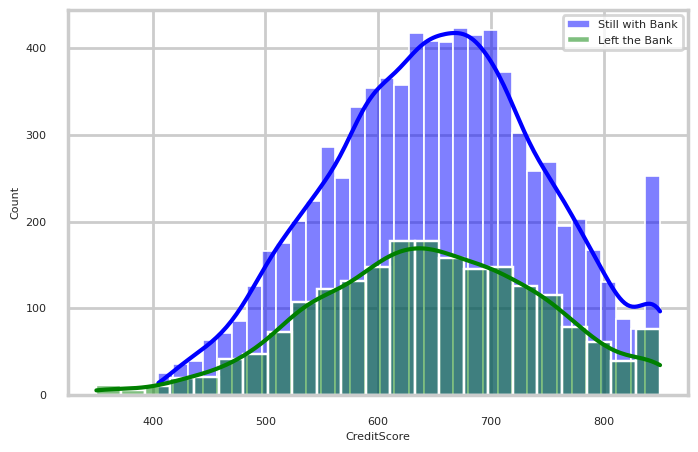

In [18]:
# Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).

sns.histplot(df_0['CreditScore'], color='blue', label='Still with Bank', kde=True)
sns.histplot(df_1['CreditScore'], color='green', label='Left the Bank', kde=True)

plt.legend(fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel(plt.gca().get_xlabel(), fontsize=8)
plt.ylabel(plt.gca().get_ylabel(), fontsize=8)
plt.show()

In [19]:
# Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).

print("H0: μ(stayed) = μ(left)")
print("H1: μ(stayed) ≠ μ(left)")
print("α = 0.05")

# t-test (Welch's t-test: does not assume equal variances)
t_stat, p_value = scipy.stats.ttest_ind(df_0.CreditScore, df_1.CreditScore, equal_var=False)

print("\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Mean values
mean_stayed = df_0['CreditScore'].mean()
mean_left = df_1['CreditScore'].mean()

print(f"\nMean CreditScore (stayed): {mean_stayed:.1f}")
print(f"Mean CreditScore (left): {mean_left:.1f}")
print(f'difference: {(mean_stayed - mean_left ):.1f}')

# Interpretation
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject H0 (p = {p_value:.6f} < {alpha})")
    print("There is a statistically significant difference in mean CreditScore between customers who stayed and those who left.")
else:
    print(f"\nConclusion: Fail to reject H0 (p = {p_value:.6f} ≥ {alpha})")
    print("There is no statistically significant difference in mean CreditScore between the two groups.")

# Customers who left the bank have ~6.5 credit score lower, which suggests CreditScore is statistically significant but with small effect size

H0: μ(stayed) = μ(left)
H1: μ(stayed) ≠ μ(left)
α = 0.05

Results:
T-statistic: 2.6347
P-value: 0.008465

Mean CreditScore (stayed): 651.9
Mean CreditScore (left): 645.4
difference: 6.5

Conclusion: Reject H0 (p = 0.008465 < 0.05)
There is a statistically significant difference in mean CreditScore between customers who stayed and those who left.


# Conclusion
Do we reject the Null Hypothesis ? Why ?

We reject the null hypothesis (p < 0.05). The difference in mean CreditScore between customers who stayed and those who left is statistically significant and unlikely due to chance. Notably, customers who stayed show a higher mean CreditScore, suggesting a potential relationship between CreditScore and churn behavior.

# Hypothesis 4: Estimated Salary

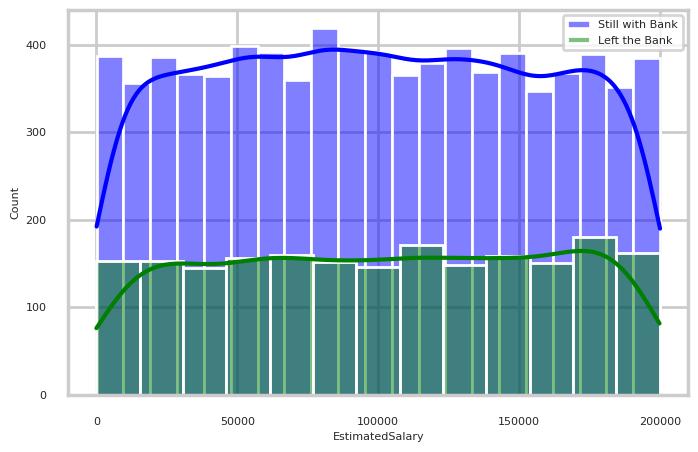

In [20]:
# Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.
sns.histplot(df_0['EstimatedSalary'], color='blue', label='Still with Bank', kde=True)
sns.histplot(df_1['EstimatedSalary'], color='green', label='Left the Bank', kde=True)

plt.legend(fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel(plt.gca().get_xlabel(), fontsize=8)
plt.ylabel(plt.gca().get_ylabel(), fontsize=8)
plt.show()

In [21]:
# Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.

print("H0: μ(stayed) = μ(left)")
print("H1: μ(stayed) ≠ μ(left)")
print("α = 0.05")

# t-test (Welch's t-test: does not assume equal variances)
t_stat, p_value = scipy.stats.ttest_ind(df_0.EstimatedSalary, df_1.EstimatedSalary, equal_var=False)

print("\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Mean values
mean_stayed = df_0['EstimatedSalary'].mean()
mean_left = df_1['EstimatedSalary'].mean()

print(f"\nMean EstimatedSalary (stayed): {mean_stayed:.1f}")
print(f"Mean EstimatedSalary (left): {mean_left:.1f}")
print(f'difference: {(mean_stayed - mean_left ):.1f}')

# Interpretation
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject H0 (p = {p_value:.6f} < {alpha})")
    print("There is a statistically significant difference in mean EstimatedSalary between customers who stayed and those who left.")
else:
    print(f"\nConclusion: Fail to reject H0 (p = {p_value:.6f} ≥ {alpha})")
    print("There is no statistically significant difference in mean EstimatedSalary between the two groups." )

H0: μ(stayed) = μ(left)
H1: μ(stayed) ≠ μ(left)
α = 0.05

Results:
T-statistic: -1.2034
P-value: 0.228925

Mean EstimatedSalary (stayed): 99738.4
Mean EstimatedSalary (left): 101465.7
difference: -1727.3

Conclusion: Fail to reject H0 (p = 0.228925 ≥ 0.05)
There is no statistically significant difference in mean EstimatedSalary between the two groups.


# Using Bootstrapping

In [22]:
# Calculate the difference in means and shift the EstimatedSalary for both groups.
diff_means = np.mean(df_1.EstimatedSalary) - np.mean(df_0.EstimatedSalary)
mean_salary = np.mean(df.EstimatedSalary)

display (diff_means.round(2), mean_salary.round(2) )


salary_shifted_0 = df_0.EstimatedSalary + mean_salary - np.mean(df_0.EstimatedSalary)
salary_shifted_1 = df_1.EstimatedSalary + mean_salary - np.mean(df_1.EstimatedSalary)

np.float64(1727.29)

np.float64(100090.24)

In [23]:
# Calculate the bootstrap sample means for both groups and their difference.
bs_n_0 = bs_choice(salary_shifted_0, np.mean, 10000)
bs_n_1 = bs_choice(salary_shifted_1, np.mean, 10000)
bs_mean = bs_n_1 - bs_n_0

In [24]:
# Calculate the p-value based on the bootstrap distribution of the difference in means.

p = np.sum(np.abs(bs_mean) >= np.abs(diff_means)) / len(bs_mean)
p

# consistent across parametric (t-test) and non-parametric (bootstrap) approaches

np.float64(0.2267)

# Conclusion
Do we reject the Null Hypothesis ? Why ?

We fail to reject the null hypothesis. Both the t-test (p = 0.229) and bootstrap (p = 0.231) yield p-values greater than α = 0.05, indicating that the difference in mean EstimatedSalary between customers who stayed and those who left is not statistically significant and could be due to random chance.

# Final Conclusion
What will be the most helpful feature in predicting churning?

Based on the analysis, Age is the strongest predictor of churn, with customers who leave being significantly older. CreditScore also shows a statistically significant, although with a smaller effect size.

Balance appears significant only due to zero-balance accounts, and loses importance when considering active customers. EstimatedSalary does not show a meaningful relationship with churn.

Banks should focus retention strategies on older and potentially inactive customers.

# Machine Learning
Create a predictive model that identifies customers who are likely to churn, helping the bank to focus retention efforts on high-risk customers.

In [25]:
# Exploratory Data Analysis

print ('\nfirst 5 rows')
print(df.head())

print ('\nShape database')  # dataset of 10.000 Customers x 14 columns
print(df.shape)

print ('\nInfo')  # mix numerical + categorical + binary columns
print(df.info())  #no missing values

#  0   RowNumber        irrelevant, drop
#  1   CustomerId       irrelevant, drop
#  2   Surname          irrelevant, drop
#  3   CreditScore      → credit score
#  4   Geography        → country (France, Spain, Germany) →  convert to category
#  5   Gender           → gender, convert to binary  0 - 1
#  6   Age              → age
#  7   Tenure           → years as a customer
#  8   Balance          → account balance --> a lot fo clients with cero balance
#  9   NumOfProducts    → products held
#  10  HasCrCard        → has a card (0/1) convert to binary
#  11  IsActiveMember   → active customer (0/1) convert to binary
#  12  EstimatedSalary  → estimated salary
#  13  Exited           → target (0 = stays, 1 = leaves)


print()
print(f'Duplicates: {df.duplicated().any()}')  #no duplicates

print ('\ndescribe')
print(df.describe())


first 5 rows
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  

In [26]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [27]:
#data type convertion

df['Geography'] = df['Geography'].astype('category')

df['Gender'] = df['Gender'].str.strip().str.capitalize()
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})


In [28]:
df['Gender'].unique()

array([0, 1])

In [29]:
df.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,category
Gender,int64
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


In [30]:
# How many customers left the bank? 20.37%

#unbalanced classes

display (df.groupby('Exited')
   .size()
   .reset_index(name='Count')
   .assign(Percentage=lambda x: (x['Count'] / x['Count'].sum() * 100).round(2))
)

,Exited,Count,Percentage
0,0,7963,79.63
1,1,2037,20.37


In [31]:
# Define variables: features and target

y = df['Exited']  # target = what I want to predict
X = df.drop(['Exited', 'RowNumber', 'CustomerId', 'Surname'], axis=1)

#  0   RowNumber        irrelevant, drop
#  1   CustomerId       irrelevant, drop
#  2   Surname          irrelevant, drop

In [32]:
# features: column types

numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance',  'NumOfProducts', 'EstimatedSalary']

categorical_features = ['Geography']

binary_features = ['Gender', 'HasCrCard', 'IsActiveMember']


#  3   CreditScore      → credit score
#  6   Age              → age
#  7   Tenure           → years as a customer
#  8   Balance          → account balance
#  9   NumOfProducts    → products held
#  12  EstimatedSalary  → estimated salary

#  4   Geography        → country (France, Spain, Germany) →  convert to category

#  5   Gender           → gender, convert to binary  0 - 1
#  10  HasCrCard        → has a card (0/1) convert to binary
#  11  IsActiveMember   → active customer (0/1) convert to binary

In [33]:
# Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('bin', 'passthrough', binary_features)
    ]
)

In [34]:
# train vs test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,       # independent variables
    y,       # target variable
    test_size=0.2,
    random_state=42,
    stratify=y  #same proportion, maintaining the class ratio
)

print()
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print()
display(y_train.mean()) # ~0.20375
display(y_test.mean())  # ~0.2035


Train shape: (8000, 10)
Test shape: (2000, 10)



np.float64(0.20375)

np.float64(0.2035)

=== Logistic Regression V1 === 

Accuracy: 0.81
Precision: 0.59
Recall: 0.19
F1: 0.28


/tmp/ipykernel_14642/2188411165.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=8)


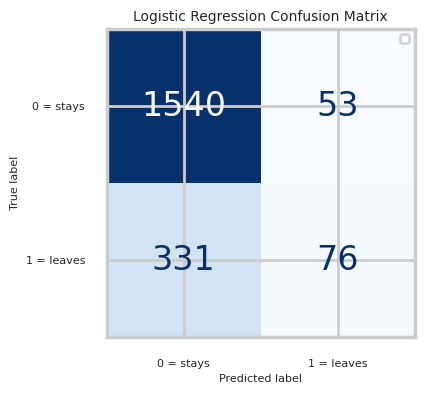

In [35]:
# Pipeline - Train - Predict - Evaluate  for LogisticRegression V1

pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))  # baseline
])

pipeline.fit(X_train, y_train)  # training part

y_pred_lr1 = pipeline.predict(X_test)  # prediction part

# Evaluation part
print("=== Logistic Regression V1 === \n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr1):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_lr1):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_lr1):.2f}")
print(f"F1: {f1_score(y_test, y_pred_lr1):.2f}")

cm = confusion_matrix(y_test, y_pred_lr1)
disp = ConfusionMatrixDisplay(cm, display_labels=['0 = stays', '1 = leaves'])
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title(f'Logistic Regression Confusion Matrix',fontsize=10)
plt.legend(fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel(plt.gca().get_xlabel(), fontsize=8)
plt.ylabel(plt.gca().get_ylabel(), fontsize=8)
plt.show()

In [36]:
# Accuracy = 0.81  ✔ the model achieved a relatively high accuracy
# Precision = 0.59  ~
# Recall = 0.19 → 💣 low! The model is missing almost all churn customers. This is likely due to class imbalance
# F1: 0.28  low!

# To be able to detect churn customers early, we need to increase recall, even if it means more false alarms.
# It's better to err on the side of caution than to underestimate.

=== Logistic Regression V2 === 

Accuracy: 0.71
Precision: 0.39
Recall: 0.70
F1: 0.50


/tmp/ipykernel_14642/3460079164.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=8)


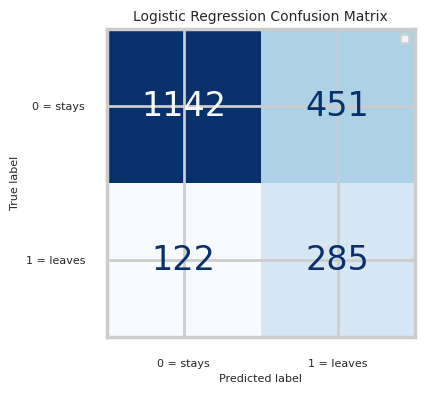

In [37]:
# Pipeline - Train - Predict - Evaluate  for LogisticRegression with class weighting V2

pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))  # forces the model to pay attention to churners.
])

pipeline.fit(X_train, y_train)  # training part

y_pred_lr2 = pipeline.predict(X_test)  # prediction part

# Evaluation part
print("=== Logistic Regression V2 === \n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr2):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_lr2):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_lr2):.2f}")
print(f"F1: {f1_score(y_test, y_pred_lr2):.2f}")

cm = confusion_matrix(y_test, y_pred_lr2)
disp = ConfusionMatrixDisplay(cm, display_labels=['0 = stays', '1 = leaves'])
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title(f'Logistic Regression Confusion Matrix',fontsize=10)
plt.legend(fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel(plt.gca().get_xlabel(), fontsize=8)
plt.ylabel(plt.gca().get_ylabel(), fontsize=8)
plt.show()

In [38]:
#  Better metrics: recall and F1 go up, but accuracy and precision go down.
# Accuracy: 0.71   ~
# Precision: 0.39  ~
# Recall: 0.70  ✔
# F1: 0.50  ✔

=== Logistic Regression V3 === 

Accuracy: 0.65
Precision: 0.35
Recall: 0.82
F1: 0.49


/tmp/ipykernel_14642/1336898064.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=8)


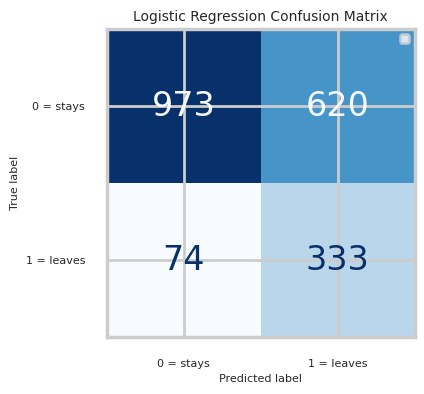

In [39]:
# Pipeline - Train - Predict - Evaluate  for LogisticRegression with class weighting and threshold = 0.43 V3

threshold = 0.43

pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

pipeline.fit(X_train, y_train)  # training part

y_probs = pipeline.predict_proba(X_test)[:, 1] # prediction part
y_pred_lr3 = (y_probs > threshold ).astype(int)   # custom threshold = 0.43

# Evaluation part
print("=== Logistic Regression V3 === \n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr3):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_lr3):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_lr3):.2f}")
print(f"F1: {f1_score(y_test, y_pred_lr3):.2f}")

cm = confusion_matrix(y_test, y_pred_lr3)
disp = ConfusionMatrixDisplay(cm, display_labels=['0 = stays', '1 = leaves'])
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title(f'Logistic Regression Confusion Matrix',fontsize=10)
plt.legend(fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel(plt.gca().get_xlabel(), fontsize=8)
plt.ylabel(plt.gca().get_ylabel(), fontsize=8)
plt.show()

In [40]:
# Accuracy: 0.64   ~
# Precision: 0.34   ~
# Recall: 0.83  ✔
# F1: 0.48   ~

# In this version, we adjusted the classification threshold to increase recall, allowing the model to identify most customers at risk of churn.
# Although this reduces precision, it aligns better with the business objective of minimizing customer loss.
# Trade-off: Low threshold → more positive → higher recall but lower precision (acceptable)

=== Random Forest V4 === 

Accuracy: 0.83
Precision: 0.56
Recall: 0.71
F1: 0.63


/tmp/ipykernel_14642/4267327969.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=8)


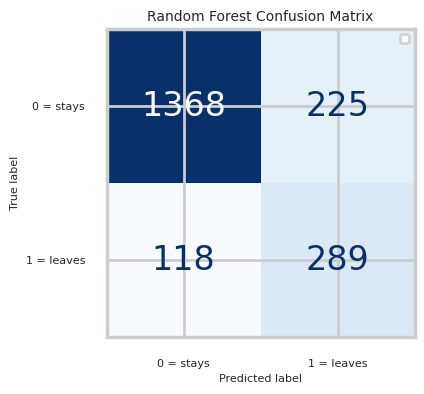

In [41]:
# Pipeline - Train - Predict - Evaluate  for Random Forest V4

rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_pipeline.fit(X_train, y_train)  # training part

y_pred_rf = rf_pipeline.predict(X_test)  # prediction part

# Evaluation part
print("=== Random Forest V4 === \n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.2f}")
print(f"F1: {f1_score(y_test, y_pred_rf):.2f}")

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['0 = stays', '1 = leaves'])
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title(f'Random Forest Confusion Matrix',fontsize=10)
plt.legend(fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel(plt.gca().get_xlabel(), fontsize=8)
plt.ylabel(plt.gca().get_ylabel(), fontsize=8)
plt.show()

In [42]:
# Accuracy: 0.83
# Precision: 0.56
# Recall: 0.71
# F1: 0.63

# Lower recall but better in other metrics, let's try the last option

=== Random Forest (threshold 0.43) ===

Accuracy: 0.78
Precision: 0.47
Recall: 0.79
F1: 0.59


/tmp/ipykernel_14642/1756852962.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=8)


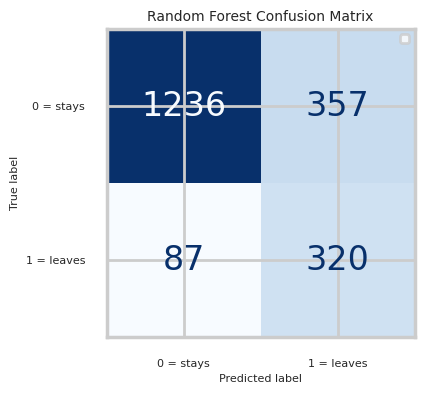

In [43]:
# RF with threshold 0.43 V5

y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

threshold = 0.43
y_pred_rf_custom = (y_proba_rf >= threshold).astype(int)

print("=== Random Forest (threshold 0.43) ===\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_custom):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_custom):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_rf_custom):.2f}")
print(f"F1: {f1_score(y_test, y_pred_rf_custom):.2f}")

cm = confusion_matrix(y_test, y_pred_rf_custom)
disp = ConfusionMatrixDisplay(cm, display_labels=['0 = stays', '1 = leaves'])
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title(f'Random Forest Confusion Matrix',fontsize=10)
plt.legend(fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel(plt.gca().get_xlabel(), fontsize=8)
plt.ylabel(plt.gca().get_ylabel(), fontsize=8)
plt.show()

,Model,Accuracy,Precision,Recall,F1
2,Logistic V3 (threshold),0.65,0.35,0.82,0.49
4,Random Forest V5 (threshold),0.78,0.47,0.79,0.59
3,Random Forest V4,0.83,0.56,0.71,0.63
1,Logistic V2 (balanced),0.71,0.39,0.70,0.50
0,Logistic V1,0.81,0.59,0.19,0.28


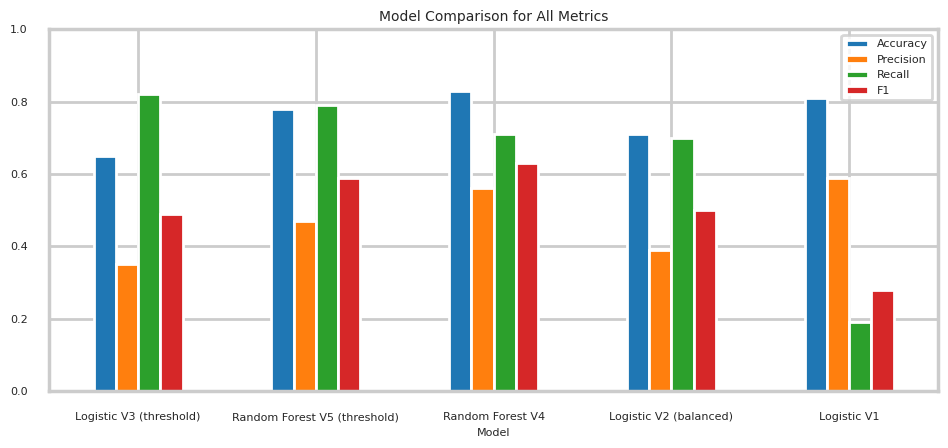

In [44]:
# Metric for all the models

results = pd.DataFrame({
    'Model': [
        'Logistic V1',
        'Logistic V2 (balanced)',
        'Logistic V3 (threshold)',
        'Random Forest V4',
        'Random Forest V5 (threshold)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr1),
        accuracy_score(y_test, y_pred_lr2),
        accuracy_score(y_test, y_pred_lr3),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_custom)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr1),
        precision_score(y_test, y_pred_lr2),
        precision_score(y_test, y_pred_lr3),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_custom)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr1),
        recall_score(y_test, y_pred_lr2),
        recall_score(y_test, y_pred_lr3),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_custom)
    ],
    'F1': [
        f1_score(y_test, y_pred_lr1),
        f1_score(y_test, y_pred_lr2),
        f1_score(y_test, y_pred_lr3),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_custom)
    ]
})

results = results.round(2)  #round

results = results.sort_values(by='Recall', ascending=False)  #sort by recall

display(results)

results_plot = results.set_index('Model')
results_plot.plot(kind='bar', figsize=(10, 5))
plt.title('Model Comparison for All Metrics',fontsize=10)
plt.xticks(rotation=0, fontsize=8)
plt.yticks(fontsize=8)
plt.ylim(0, 1.0)
plt.legend(loc='upper right', fontsize=8)

plt.xlabel(plt.gca().get_xlabel(), fontsize=8)
plt.ylabel(plt.gca().get_ylabel(), fontsize=8)
plt.tight_layout()
plt.show()

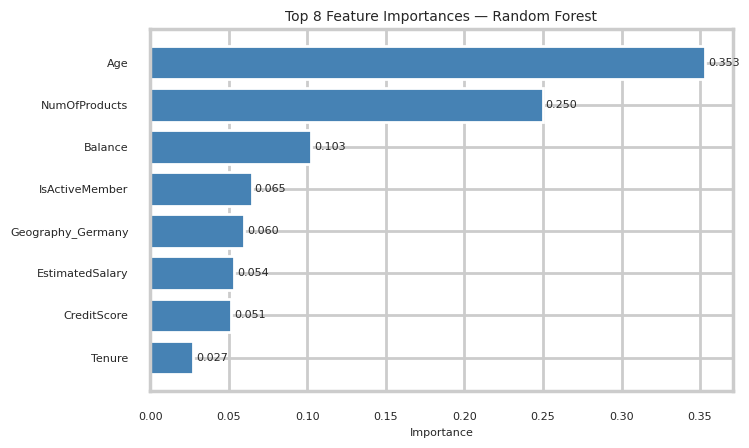

In [45]:
# Random Forest feature importance

importances = rf_pipeline.named_steps['model'].feature_importances_

feature_names = (
    numeric_features +
    list(rf_pipeline.named_steps['preprocessing']
         .named_transformers_['cat']
         .get_feature_names_out(categorical_features)) +
    binary_features
)

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

data = feat_imp.head(8)
bars = ax.barh(data['Feature'], data['Importance'], color='steelblue')

# Add value at the end of each bar
for bar, val in zip(bars, data['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left', fontsize=8)

ax.set_title('Top 8 Feature Importances — Random Forest', fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Importance', fontsize=8)
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout()
plt.show()

# **Overall Conclusion**
Inferential statistics identified Age as the strongest churn predictor, followed by CreditScore. These findings are alined to the Random Forest feature importance analysis.

Although Random Forest V4 provides the best overall balance (highest F1-score), Random Forest V5 (threshold=0.43) is preferred for business purposes:

* Recall: 0.79 — detects 79% of customers at risk of churning
* Acceptable precision trade-off given the business cost of losing a customer vs. the cost of a false alarm.